# CNC Workflow Evaluation — Analysis
Analyzes evaluation results from `output/evaluation_results.json`

**Metrics:**
- **FCR** — Feature Capture Rate (gate)
- **SCS** — Sequence Correctness Score
- **WR** — Workflow Rating
- **ROA** — Reasoning–Output Alignment (CoT/GoT/ToT only)
- **ORR** — Operational Redundancy Rate (penalty multiplier)
- **WQS** — Workflow Quality Score (final composite)

**Formula:**
$$WQS = FCR \times (1 - ORR) \times (w_1 \cdot SCS + w_2 \cdot WR + w_3 \cdot ROA)$$

In [22]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from math import pi
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'sans-serif'

In [23]:
# ── Config ────────────────────────────────────────────────────────────────────
RESULTS_FILE = "evaluation_results.json"

TECHNIQUES  = ["zero_shot", "cot", "guided_cot", "tot", "got"]
CATEGORIES  = ["simple", "medium", "hard"]
TECH_LABELS = {
    "zero_shot"  : "Zero-Shot",
    "cot"        : "CoT",
    "guided_cot" : "Guided CoT",
    "tot"        : "ToT",
    "got"        : "GoT"
}
COLORS = {
    "zero_shot"  : "#4C72B0",
    "cot"        : "#DD8452",
    "guided_cot" : "#55A868",
    "tot"        : "#C44E52",
    "got"        : "#8172B3"
}
CAT_COLORS = {"simple": "#2ecc71", "medium": "#f39c12", "hard": "#e74c3c"}

In [26]:
# ── Load Data ─────────────────────────────────────────────────────────────────
with open(RESULTS_FILE, "r") as f:
    raw = json.load(f)

df = pd.DataFrame(raw)
df["category"] = df["image_id"].apply(lambda x: x.split("_")[0])
df["img_num"]  = df["image_id"].apply(lambda x: int(x.split("_")[1]))
df["label"]    = df["technique"].map(TECH_LABELS)

print(f"Loaded {len(df)} evaluation records")
df.head()

Loaded 75 evaluation records


,image_id,technique,evaluator,file,timestamp,total_steps,total_features,addressed,fcr,scs,wr,roa,orr,wqs,notes,category,img_num,label
0,simple_1,zero_shot,Arya,output/zero_shot_results\result_simple_1_20260...,2026-02-25 00:27:30,5,3,3,1.0,1.0,1.00,NaN,0.0000,1.0000,,simple,1,Zero-Shot
1,simple_1,cot,Arya,output/cot_results\result_simple_1_20260219_15...,2026-02-25 13:44:29,5,3,3,1.0,1.0,1.00,1.0,0.0000,1.0000,,simple,1,CoT
2,simple_1,guided_cot,Arya,output/guided_cot_results\result_simple_1_2026...,2026-02-25 13:59:54,6,3,3,1.0,1.0,1.00,1.0,0.1667,0.8333,Extra: Chamfering,simple,1,Guided CoT
3,simple_1,tot,Arya,output/tot_results\result_simple_1_20260219_17...,2026-02-25 14:01:58,9,3,3,1.0,0.5,0.25,0.5,0.1111,0.3778,Wrong Orientation,simple,1,ToT
4,simple_1,got,Arya,output/got_results\result_simple_1_20260219_19...,2026-02-25 14:02:56,6,3,3,1.0,1.0,0.75,1.0,0.1667,0.7708,Extra: Chamfering,simple,1,GoT


## 1. WQS by Prompting Technique

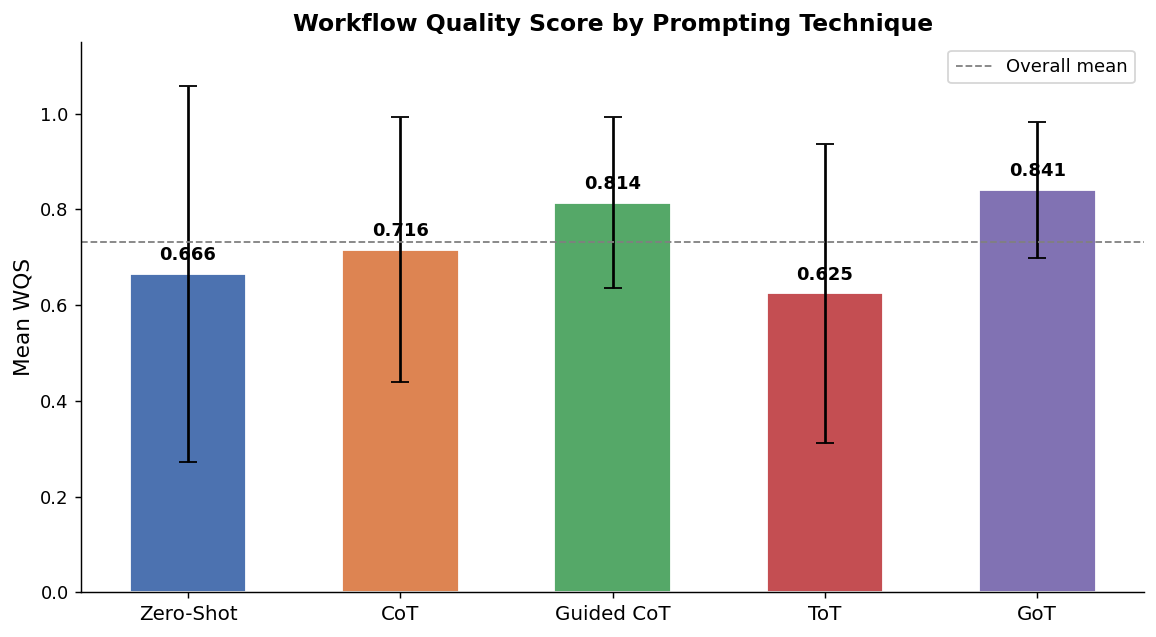

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

means = [df[df["technique"] == t]["wqs"].mean() for t in TECHNIQUES]
stds  = [df[df["technique"] == t]["wqs"].std()  for t in TECHNIQUES]
x     = np.arange(len(TECHNIQUES))

bars = ax.bar(x, means, yerr=stds, capsize=5,
              color=[COLORS[t] for t in TECHNIQUES],
              edgecolor="white", width=0.55)

for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{mean:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels([TECH_LABELS[t] for t in TECHNIQUES], fontsize=11)
ax.set_ylabel("Mean WQS", fontsize=12)
ax.set_title("Workflow Quality Score by Prompting Technique", fontsize=13, fontweight="bold")
ax.set_ylim(0, 1.15)
ax.axhline(df["wqs"].mean(), color="gray", linestyle="--", linewidth=1, label="Overall mean")
ax.legend(fontsize=10)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
# plt.savefig("output/analysis/1_wqs_by_technique.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. WQS by Difficulty Level

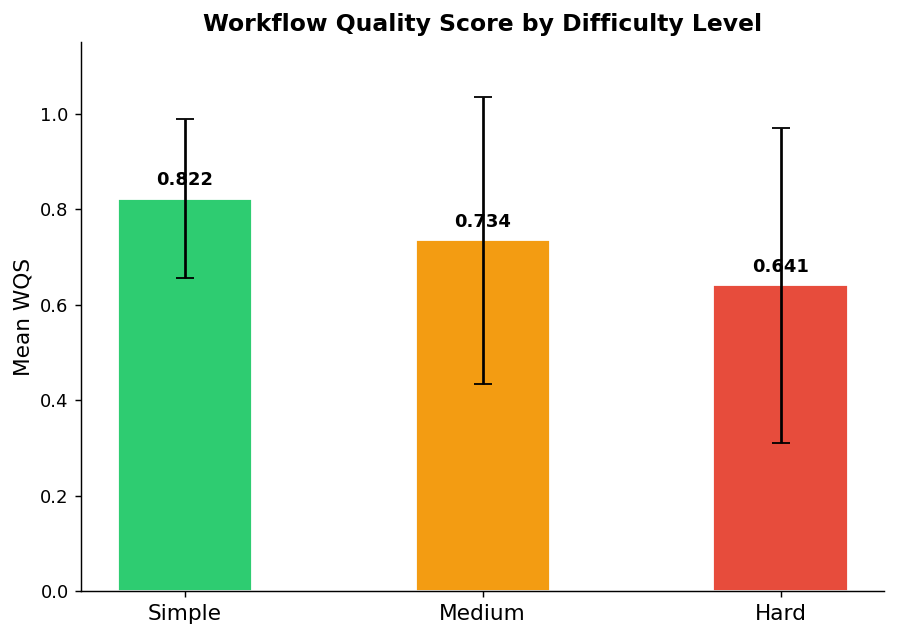

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))

means = [df[df["category"] == c]["wqs"].mean() for c in CATEGORIES]
stds  = [df[df["category"] == c]["wqs"].std()  for c in CATEGORIES]
x     = np.arange(len(CATEGORIES))

bars = ax.bar(x, means, yerr=stds, capsize=5,
              color=[CAT_COLORS[c] for c in CATEGORIES],
              edgecolor="white", width=0.45)

for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{mean:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels([c.capitalize() for c in CATEGORIES], fontsize=12)
ax.set_ylabel("Mean WQS", fontsize=12)
ax.set_title("Workflow Quality Score by Difficulty Level", fontsize=13, fontweight="bold")
ax.set_ylim(0, 1.15)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
# plt.savefig("output/analysis/2_wqs_by_difficulty.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Heatmap — Technique × Difficulty

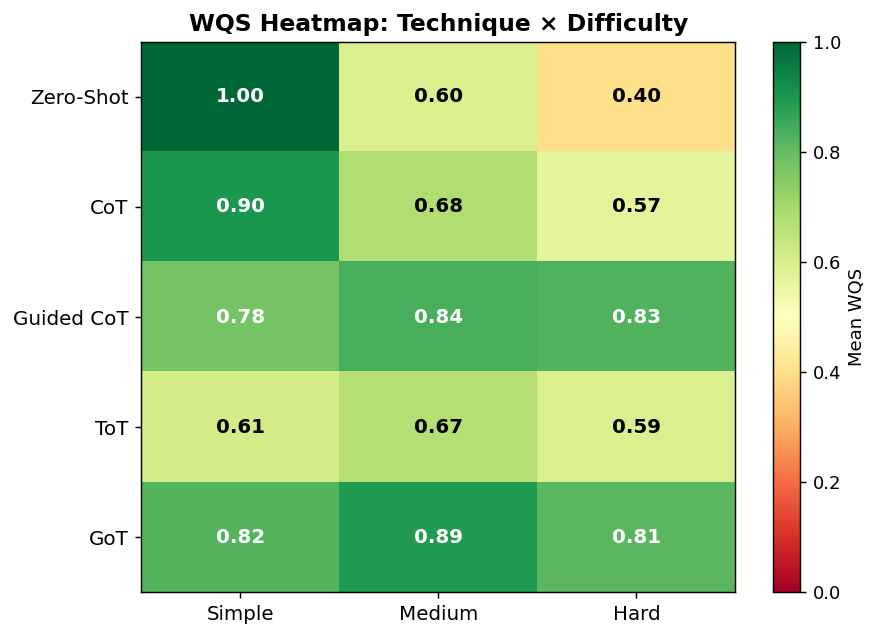

In [9]:
import os
os.makedirs("output/analysis", exist_ok=True)

matrix = np.zeros((len(TECHNIQUES), len(CATEGORIES)))
for i, t in enumerate(TECHNIQUES):
    for j, cat in enumerate(CATEGORIES):
        vals = df[(df["technique"] == t) & (df["category"] == cat)]["wqs"].dropna()
        matrix[i, j] = vals.mean() if len(vals) > 0 else np.nan

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(matrix, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")

ax.set_xticks(range(len(CATEGORIES)))
ax.set_xticklabels([c.capitalize() for c in CATEGORIES], fontsize=11)
ax.set_yticks(range(len(TECHNIQUES)))
ax.set_yticklabels([TECH_LABELS[t] for t in TECHNIQUES], fontsize=11)

for i in range(len(TECHNIQUES)):
    for j in range(len(CATEGORIES)):
        val = matrix[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=11, fontweight="bold",
                    color="black" if 0.35 < val < 0.75 else "white")

plt.colorbar(im, ax=ax, label="Mean WQS")
ax.set_title("WQS Heatmap: Technique × Difficulty", fontsize=13, fontweight="bold")
plt.tight_layout()
# plt.savefig("output/analysis/3_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Per-Metric Breakdown (Boxplots)

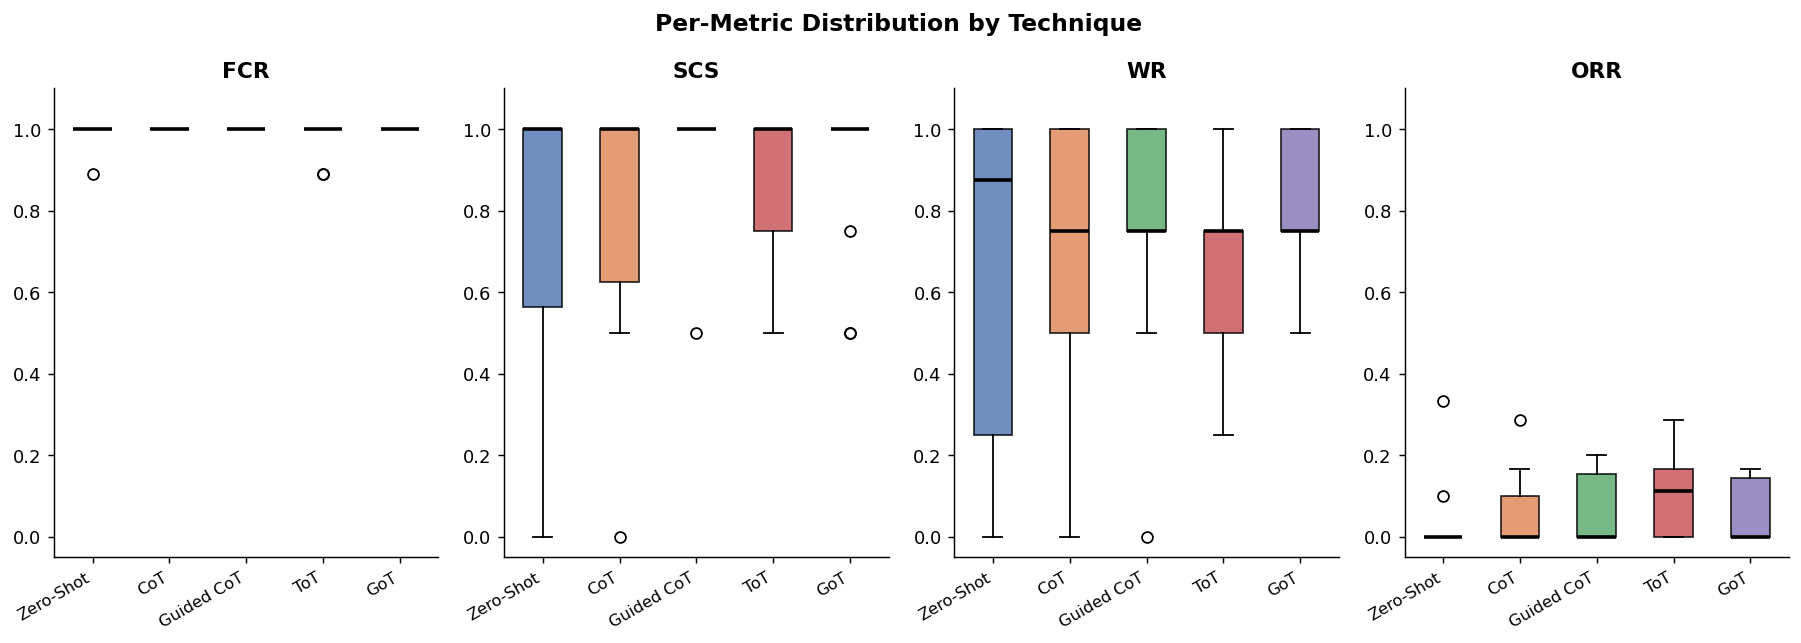

In [10]:
metrics = ["fcr", "scs", "wr", "orr"]
labels  = ["FCR", "SCS", "WR", "ORR"]

fig, axes = plt.subplots(1, 4, figsize=(14, 5), sharey=False)

for ax, metric, label in zip(axes, metrics, labels):
    data = [df[df["technique"] == t][metric].dropna().values for t in TECHNIQUES]
    bp   = ax.boxplot(data, patch_artist=True, widths=0.5,
                      medianprops=dict(color="black", linewidth=2))
    for patch, t in zip(bp["boxes"], TECHNIQUES):
        patch.set_facecolor(COLORS[t])
        patch.set_alpha(0.8)
    ax.set_xticks(range(1, len(TECHNIQUES)+1))
    ax.set_xticklabels([TECH_LABELS[t] for t in TECHNIQUES], rotation=30, ha="right", fontsize=9)
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.set_ylim(-0.05, 1.1)
    ax.spines[["top","right"]].set_visible(False)

fig.suptitle("Per-Metric Distribution by Technique", fontsize=13, fontweight="bold")
plt.tight_layout()
# plt.savefig("output/analysis/4a_metric_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()

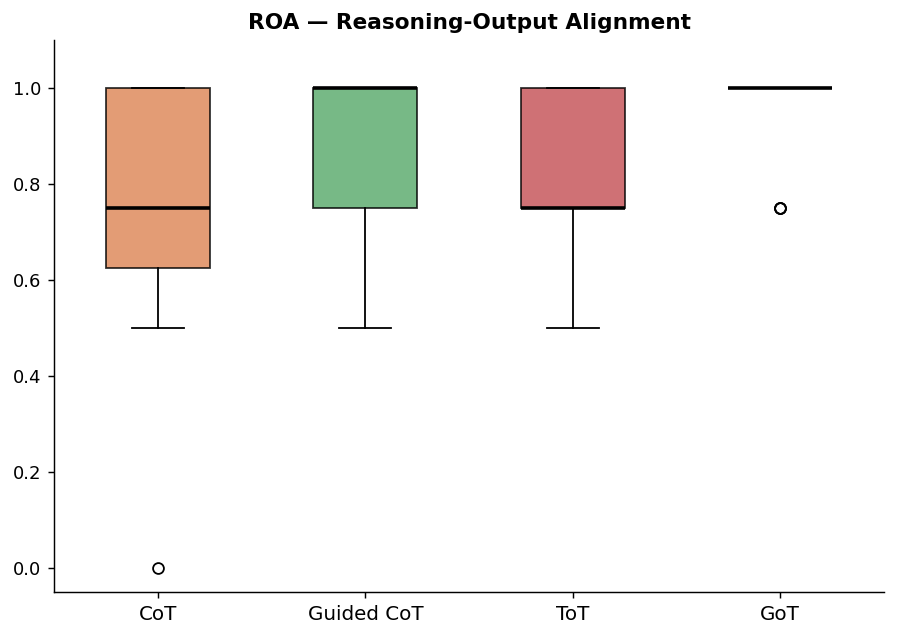

In [11]:
# ROA — reasoning techniques only
roa_techs = ["cot", "guided_cot", "tot", "got"]

fig, ax = plt.subplots(figsize=(7, 5))
data = [df[df["technique"] == t]["roa"].dropna().values for t in roa_techs]
bp   = ax.boxplot(data, patch_artist=True, widths=0.5,
                  medianprops=dict(color="black", linewidth=2))
for patch, t in zip(bp["boxes"], roa_techs):
    patch.set_facecolor(COLORS[t])
    patch.set_alpha(0.8)

ax.set_xticks(range(1, len(roa_techs)+1))
ax.set_xticklabels([TECH_LABELS[t] for t in roa_techs], fontsize=11)
ax.set_title("ROA — Reasoning-Output Alignment", fontsize=12, fontweight="bold")
ax.set_ylim(-0.05, 1.1)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
# plt.savefig("output/analysis/4b_roa_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. FCR Gate Impact

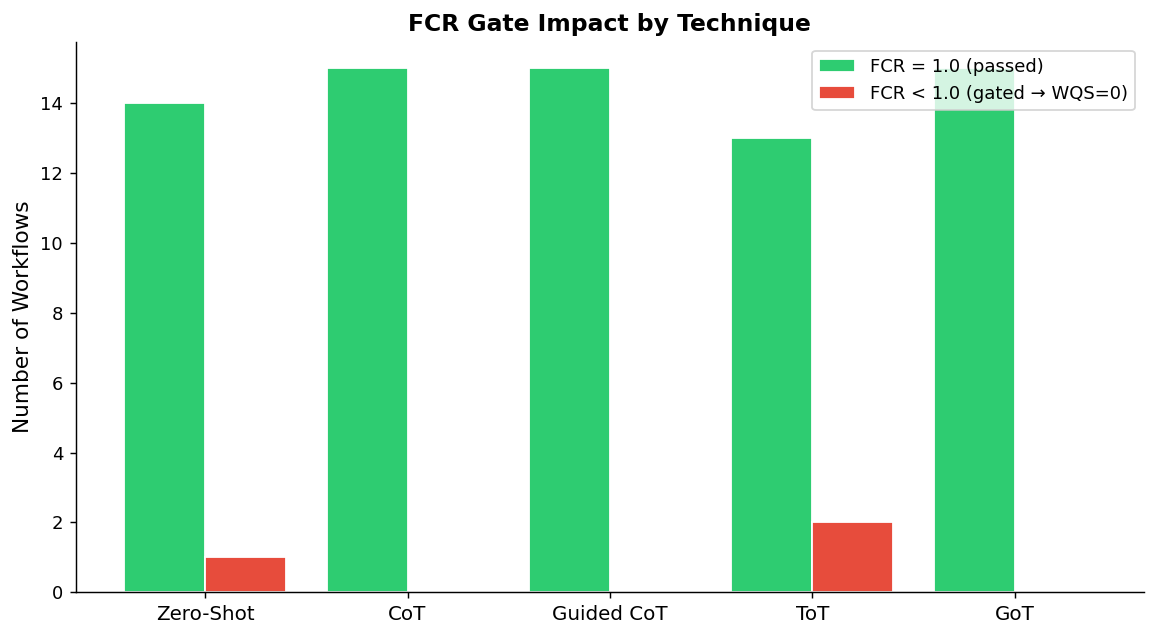

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))

passed = [(df[df["technique"] == t]["fcr"] >= 1.0).sum() for t in TECHNIQUES]
failed = [(df[df["technique"] == t]["fcr"] <  1.0).sum() for t in TECHNIQUES]
x      = np.arange(len(TECHNIQUES))

ax.bar(x - 0.2, passed, 0.4, label="FCR = 1.0 (passed)",        color="#2ecc71", edgecolor="white")
ax.bar(x + 0.2, failed, 0.4, label="FCR < 1.0 (gated → WQS=0)", color="#e74c3c", edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels([TECH_LABELS[t] for t in TECHNIQUES], fontsize=11)
ax.set_ylabel("Number of Workflows", fontsize=12)
ax.set_title("FCR Gate Impact by Technique", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
# plt.savefig("output/analysis/5_fcr_gate_impact.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. ROA vs WQS Correlation

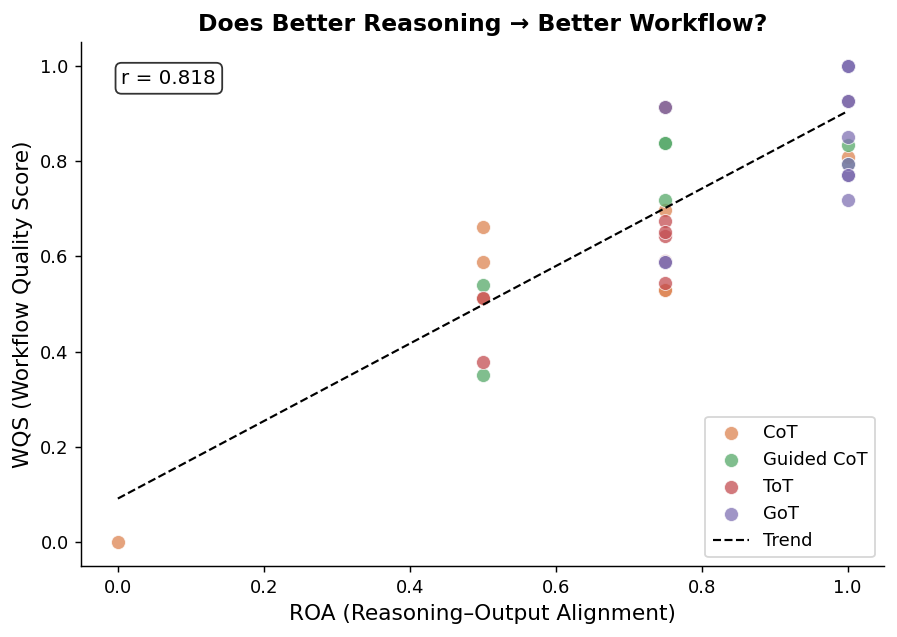

In [13]:
roa_techs = ["cot", "guided_cot", "tot", "got"]

fig, ax = plt.subplots(figsize=(7, 5))
for t in roa_techs:
    sub = df[(df["technique"] == t) & df["roa"].notna()]
    ax.scatter(sub["roa"], sub["wqs"], label=TECH_LABELS[t],
               color=COLORS[t], alpha=0.75, s=60, edgecolors="white", linewidth=0.5)

sub_all = df[df["roa"].notna()]
if len(sub_all) > 1:
    z  = np.polyfit(sub_all["roa"], sub_all["wqs"], 1)
    p  = np.poly1d(z)
    xs = np.linspace(0, 1, 100)
    ax.plot(xs, p(xs), "k--", linewidth=1.2, label="Trend")

corr = sub_all[["roa","wqs"]].corr().iloc[0,1]
ax.text(0.05, 0.92, f"r = {corr:.3f}", transform=ax.transAxes, fontsize=11,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

ax.set_xlabel("ROA (Reasoning–Output Alignment)", fontsize=12)
ax.set_ylabel("WQS (Workflow Quality Score)", fontsize=12)
ax.set_title("Does Better Reasoning → Better Workflow?", fontsize=13, fontweight="bold")
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=10)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
# plt.savefig("output/analysis/6_roa_vs_wqs.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. ORR by Technique

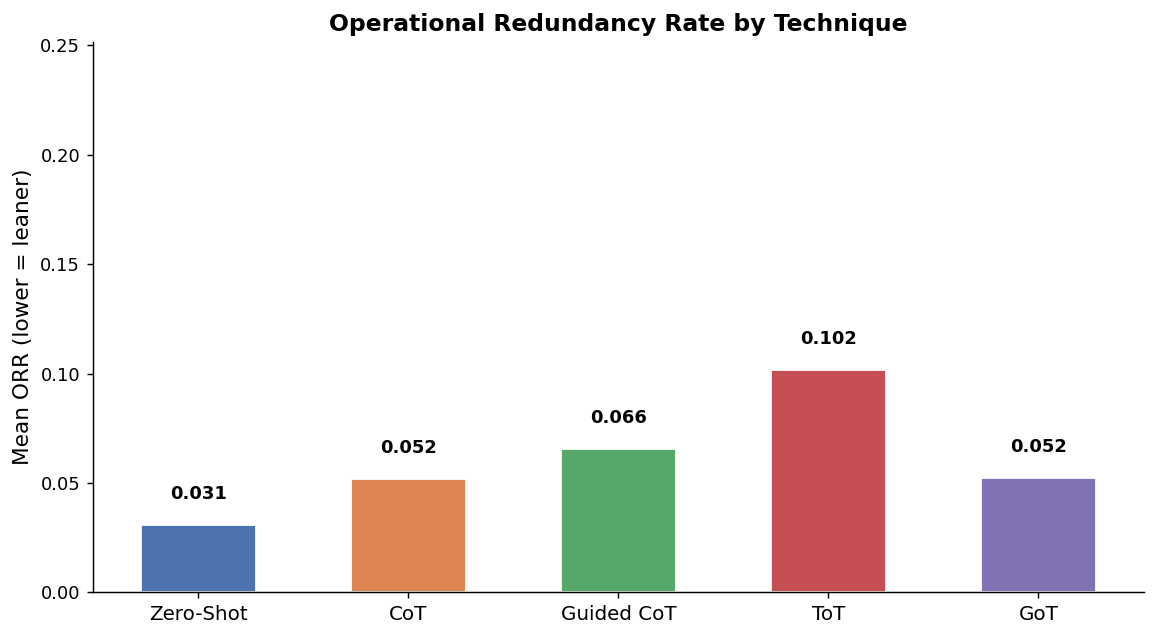

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))

means = [df[df["technique"] == t]["orr"].dropna().mean() for t in TECHNIQUES]
x     = np.arange(len(TECHNIQUES))
bars  = ax.bar(x, means, color=[COLORS[t] for t in TECHNIQUES], edgecolor="white", width=0.55)

for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{mean:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels([TECH_LABELS[t] for t in TECHNIQUES], fontsize=11)
ax.set_ylabel("Mean ORR (lower = leaner)", fontsize=12)
ax.set_title("Operational Redundancy Rate by Technique", fontsize=13, fontweight="bold")
ax.set_ylim(0, max(means) + 0.15 if max(means) > 0 else 0.3)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
# plt.savefig("output/analysis/7_orr_by_technique.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Radar Chart — Technique Metric Fingerprint

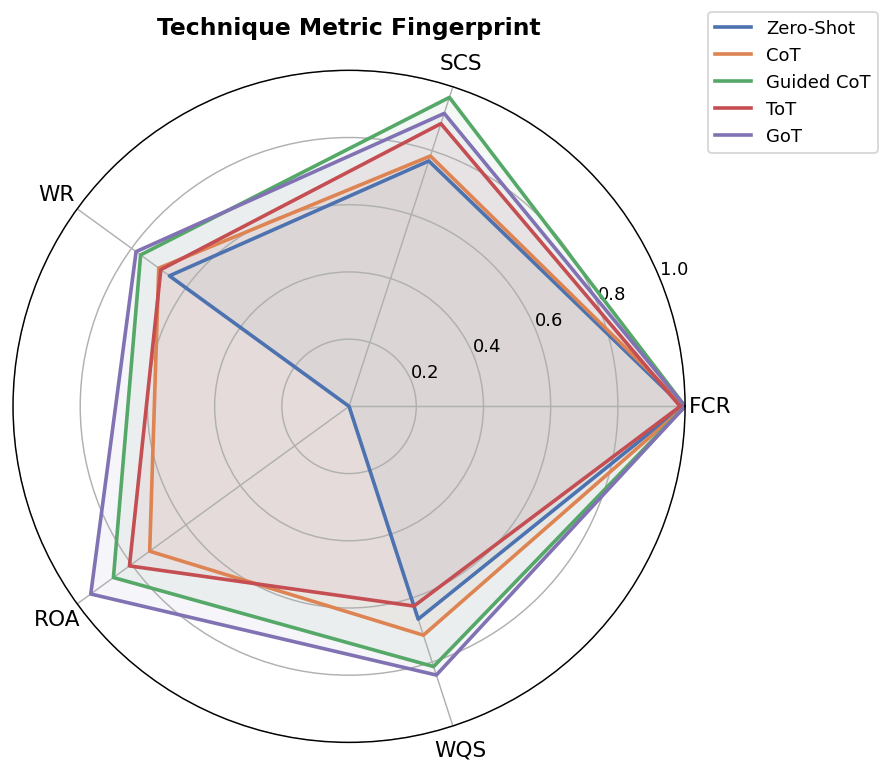

In [15]:
metrics       = ["fcr", "scs", "wr", "roa", "wqs"]
metric_labels = ["FCR", "SCS", "WR", "ROA", "WQS"]
N             = len(metrics)
angles        = [n / float(N) * 2 * pi for n in range(N)]
angles       += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for t in TECHNIQUES:
    sub    = df[df["technique"] == t]
    values = [sub[m].dropna().mean() for m in metrics]
    values = [v if not np.isnan(v) else 0 for v in values]
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=TECH_LABELS[t], color=COLORS[t])
    ax.fill(angles, values, alpha=0.07, color=COLORS[t])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_labels, fontsize=12)
ax.set_ylim(0, 1)
ax.set_title("Technique Metric Fingerprint", fontsize=13, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=10)
plt.tight_layout()
# plt.savefig("output/analysis/8_radar_chart.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Summary Table

In [16]:
rows = []
for t in TECHNIQUES:
    sub = df[df["technique"] == t]
    rows.append({
        "Technique" : TECH_LABELS[t],
        "FCR"       : round(sub["fcr"].mean(), 3),
        "SCS"       : round(sub["scs"].dropna().mean(), 3),
        "WR"        : round(sub["wr"].dropna().mean(), 3),
        "ROA"       : round(sub["roa"].dropna().mean(), 3) if sub["roa"].notna().any() else "N/A",
        "ORR"       : round(sub["orr"].dropna().mean(), 3),
        "WQS"       : round(sub["wqs"].mean(), 3),
    })

summary = pd.DataFrame(rows).set_index("Technique")
display(summary.style.background_gradient(cmap="RdYlGn", subset=["WQS", "FCR", "SCS", "WR"]))

,FCR,SCS,WR,ROA,ORR,WQS
Technique,,,,,,
Zero-Shot,0.993000,0.768000,0.661000,N/A,0.031000,0.666000
CoT,1.000000,0.783000,0.700000,0.733000,0.052000,0.716000
Guided CoT,1.000000,0.967000,0.767000,0.867000,0.066000,0.814000
ToT,0.985000,0.885000,0.692000,0.808000,0.102000,0.625000
GoT,1.000000,0.917000,0.783000,0.950000,0.052000,0.841000


In [17]:
# Difficulty breakdown
diff_rows = []
for cat in CATEGORIES:
    vals = df[df["category"] == cat]["wqs"]
    diff_rows.append({
        "Difficulty" : cat.capitalize(),
        "Mean WQS"   : round(vals.mean(), 3),
        "Std"        : round(vals.std(), 3),
        "Min"        : round(vals.min(), 3),
        "Max"        : round(vals.max(), 3),
    })

diff_summary = pd.DataFrame(diff_rows).set_index("Difficulty")
display(diff_summary.style.background_gradient(cmap="RdYlGn", subset=["Mean WQS"]))

,Mean WQS,Std,Min,Max
Difficulty,,,,
Simple,0.822000,0.166000,0.378000,1.000000
Medium,0.734000,0.300000,0.000000,1.000000
Hard,0.641000,0.329000,0.000000,1.000000
